<a href="https://colab.research.google.com/github/PaolaVergaraHernandez/MachineLearning/blob/main/PracticaFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practica Final
Integrantes:
Paola Vergara Hernandez
Daniel


En este primer bloque cargamos las librerías necesarias para la manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`), métricas de evaluación (`sklearn.metrics`), división de muestras (`train_test_split`) y el algoritmo **XGBoost** (`XGBRegressor`).

Cargamos el archivo `autos2.csv` que contiene las características y precios de los vehículos.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Cargar dataset
df = pd.read_csv("autos2 (1).csv")

# Mostrar primeras filas para verificar carga
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low




Para evaluar el comportamiento del algoritmo, crearemos exactamente **30 modelos distintos** alternando:
1. **6 conjuntos de variables predictoras ($X$):** Combinando dimensiones, potencia, consumo y peso del auto.
2. **5 conjuntos de hiperparámetros de XGBoost:** Modificando la profundidad máxima (`max_depth`), la tasa de aprendizaje (`learning_rate`), el número de estimadores (`n_estimators`) y submuestreo (`subsample`, `colsample_bytree`).

Multiplicando $6 \times 5 = 30$ combinaciones únicas. Mantendremos **`random_state=42` fijo** en todo el proceso.

In [3]:
# 1. Definir 6 combinaciones de variables predictoras
var_set_1 = [
    'horsepower',
    'engine-size',
    'bore',
    'stroke',
    'compression-ratio',
]
var_set_2 = [
    'horsepower',
    'engine-size',
    'city-mpg',
    'wheel-base',
    'bore',
    'curb-weight',
]
var_set_3 = ['horsepower', 'engine-size', 'city-mpg', 'highway-mpg', 'peak-rpm']
var_set_4 = [
    'engine-size',
    'curb-weight',
    'wheel-base',
    'horsepower',
    'city-mpg',
    'highway-mpg',
    'bore',
]
var_set_5 = ['horsepower', 'engine-size', 'curb-weight']
var_set_6 = ['engine-size', 'curb-weight', 'city-mpg', 'highway-mpg']

all_var_sets = [var_set_1, var_set_2, var_set_3, var_set_4, var_set_5, var_set_6]
all_var_sets = [
    [col for col in v_set if col in df.columns] for v_set in all_var_sets
]

# 2. Definir 5 combinaciones de hiperparámetros para XGBoost
xgb_params_list = [
    {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3},
    {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6},
    {
        'n_estimators': 200,
        'learning_rate': 0.05,
        'max_depth': 5,
        'subsample': 0.8,
    },
    {
        'n_estimators': 300,
        'learning_rate': 0.01,
        'max_depth': 7,
        'colsample_bytree': 0.7,
    },
]

# Generar 30 configuraciones (6 vars x 5 params)
configurations = []
model_counter = 1
for var_list in all_var_sets:
  for params in xgb_params_list:
    configurations.append((model_counter, var_list, params))
    model_counter += 1



En esta sección ejecutamos un bucle que entrena de manera secuencial cada uno de los 30 modelos.
Para cada modelo:
* Se dividen los datos en entrenamiento (80%) y prueba (20%) con `random_state=42`.
* Se entrena el modelo `XGBRegressor` con los parámetros correspondientes y `random_state=42`.
* Se calculan e imprimen las métricas de rendimiento: $R^2$ (Entrenamiento), $R^2$ (Prueba), Error Cuadrático Medio (MSE) y la Raíz del Error Cuadrático Medio (RMSE).

In [4]:
results_list = []

print("=" * 80)
print("INICIANDO EL ENTRENAMIENTO DE LOS 30 MODELOS DE XGBOOST")
print("=" * 80)

for m_id, features, params in configurations:
  X = df[features]
  y = df['price']

  # División fija
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  # Entrenamiento del modelo XGBoost con random_state=42
  xgb_model = XGBRegressor(**params, random_state=42, eval_metric='rmse')
  xgb_model.fit(X_train, y_train)

  # Predicciones
  y_pred_train = xgb_model.predict(X_train)
  y_pred_test = xgb_model.predict(X_test)

  # Métricas
  r2_train = r2_score(y_train, y_pred_train)
  r2_test = r2_score(y_test, y_pred_test)
  mse_val = mean_squared_error(y_test, y_pred_test)
  rmse_val = np.sqrt(mse_val)

  # Salida en consola
  print(f"\n#################### MODELO {m_id} ####################")
  print(f"Resultados del Modelo {m_id} con parámetros: {params}")
  print(f"Variables: {features}")
  print(f"R² en entrenamiento: {r2_train:.6f}")
  print(f"R² en prueba: {r2_test:.6f}")
  print(f"Error cuadrático medio (MSE): {mse_val:.2f}")
  print(f"Raíz del Error cuadrático medio (RMSE): {rmse_val:.2f}")

  results_list.append({
      'Modelo': f'Modelo {m_id}',
      'Variables': ', '.join(features),
      'Parametros': str(params),
      'R2_Train': r2_train,
      'R2_Test': r2_test,
      'MSE': mse_val,
      'RMSE': rmse_val,
      'y_test': y_test,
      'y_pred_test': y_pred_test,
  })

df_summary = pd.DataFrame(results_list)

INICIANDO EL ENTRENAMIENTO DE LOS 30 MODELOS DE XGBOOST

#################### MODELO 1 ####################
Resultados del Modelo 1 con parámetros: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3}
Variables: ['horsepower', 'engine-size', 'bore', 'stroke', 'compression-ratio']
R² en entrenamiento: 0.949474
R² en prueba: 0.918547
Error cuadrático medio (MSE): 9965482.29
Raíz del Error cuadrático medio (RMSE): 3156.82

#################### MODELO 2 ####################
Resultados del Modelo 2 con parámetros: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4}
Variables: ['horsepower', 'engine-size', 'bore', 'stroke', 'compression-ratio']
R² en entrenamiento: 0.970408
R² en prueba: 0.924712
Error cuadrático medio (MSE): 9211203.59
Raíz del Error cuadrático medio (RMSE): 3035.00

#################### MODELO 3 ####################
Resultados del Modelo 3 con parámetros: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
Variables: ['horsepower', 'engine-size', 'bo



Ordenamos la totalidad de los 30 modelos en función de su coeficiente de determinación en prueba ($R^2$ Test) de manera descendente y por su RMSE de manera ascendente.
Con esto extraemos los **3 mejores modelos** (mayor capacidad de generalización) y los **3 peores modelos** (mayor sobreajuste o subajuste).

In [5]:
df_sorted = df_summary.sort_values(
    by=['R2_Test', 'RMSE'], ascending=[False, True]
)

mejores_3 = df_sorted.head(3).copy()
mejores_3['Categoria'] = 'MEJOR'

peores_3 = df_sorted.tail(3).copy()
peores_3['Categoria'] = 'PEOR'

tabla_comparativa = pd.concat([mejores_3, peores_3])

display(
    tabla_comparativa[
        [
            'Categoria',
            'Modelo',
            'Variables',
            'Parametros',
            'R2_Train',
            'R2_Test',
            'RMSE',
        ]
    ]
)

,Categoria,Modelo,Variables,Parametros,R2_Train,R2_Test,RMSE
26,MEJOR,Modelo 27,"engine-size, curb-weight, city-mpg","{'n_estimators': 100, 'learning_rate': 0.1, 'm...",0.984308,0.941742,2669.761678
23,MEJOR,Modelo 24,"horsepower, engine-size, curb-weight","{'n_estimators': 200, 'learning_rate': 0.05, '...",0.995207,0.940003,2709.329472
21,MEJOR,Modelo 22,"horsepower, engine-size, curb-weight","{'n_estimators': 100, 'learning_rate': 0.1, 'm...",0.988433,0.936364,2790.285675
9,PEOR,Modelo 10,"horsepower, engine-size, city-mpg, wheel-base,...","{'n_estimators': 300, 'learning_rate': 0.01, '...",0.981444,0.896854,3552.398341
14,PEOR,Modelo 15,"horsepower, engine-size, city-mpg, peak-rpm","{'n_estimators': 300, 'learning_rate': 0.01, '...",0.962142,0.882708,3788.174518
4,PEOR,Modelo 5,"horsepower, engine-size, bore, stroke, compres...","{'n_estimators': 300, 'learning_rate': 0.01, '...",0.957656,0.873616,3932.260608




Generamos gráficos de dispersión (*scatter plots*) comparando los valores reales de los autos frente a las predicciones generadas por el modelo en el conjunto de prueba.
* **Línea azul punteada ($y=x$):** Representa el ajuste perfecto (predicción exactamente igual al valor real).

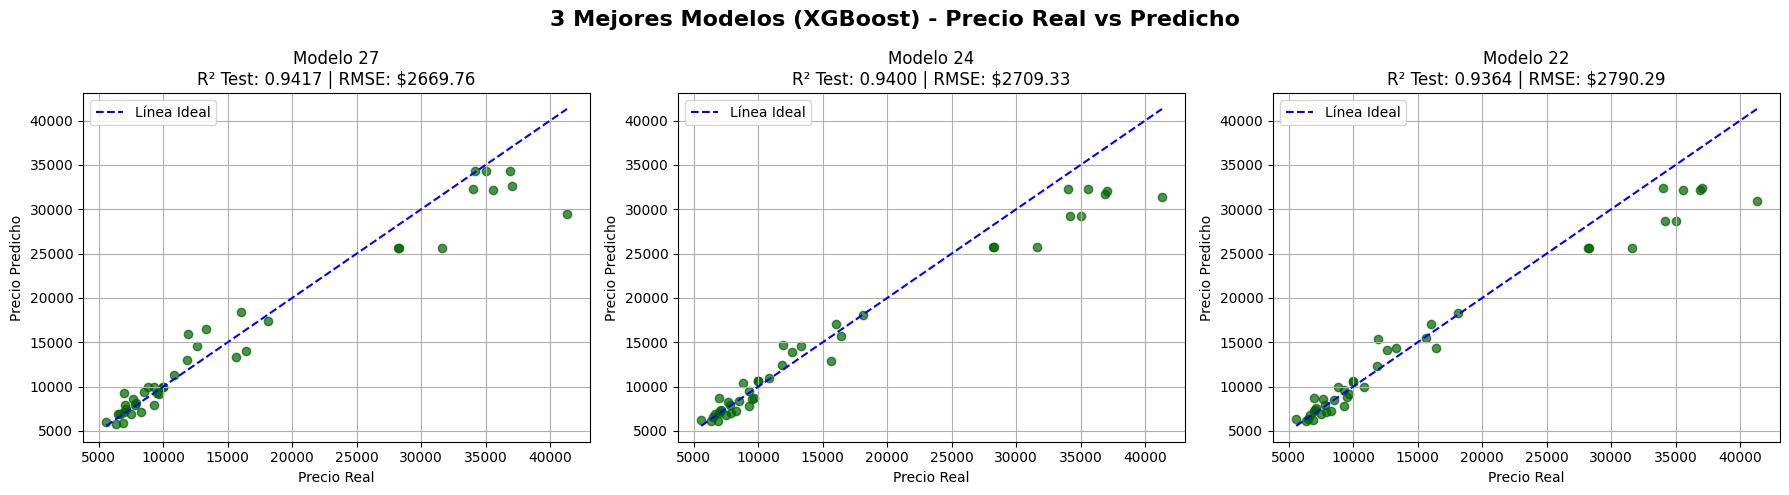

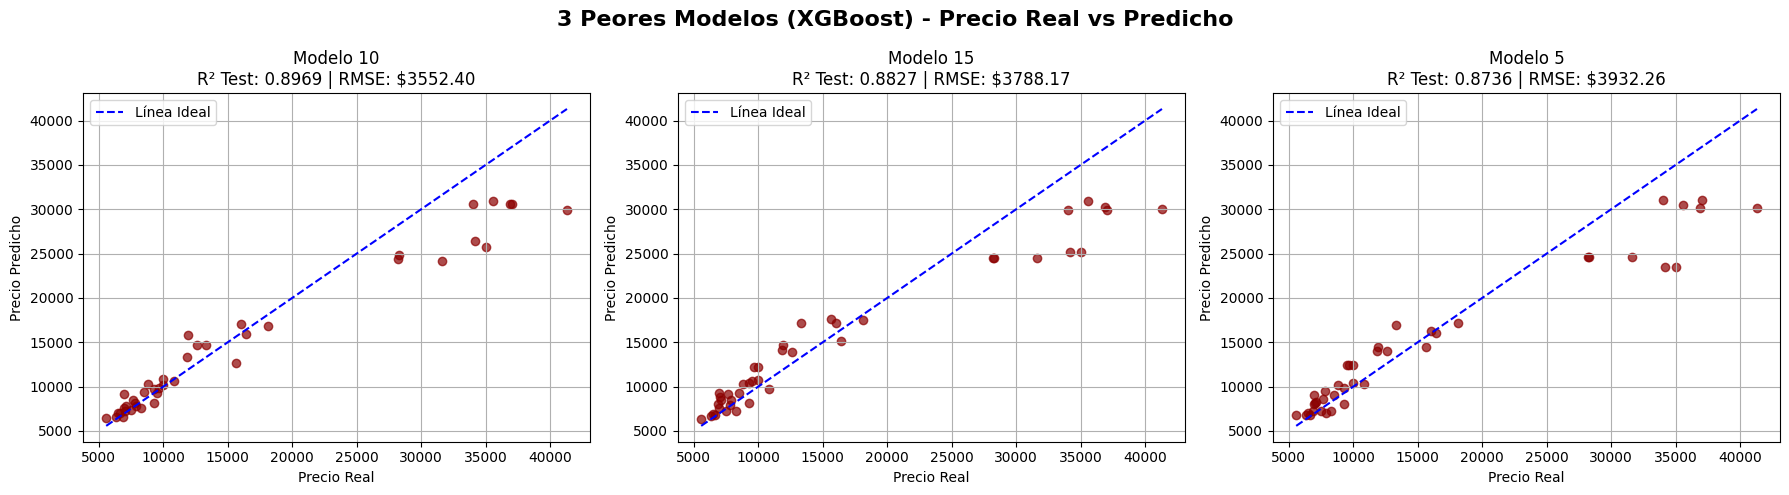

In [6]:
# Gráfica: 3 Mejores Modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    '3 Mejores Modelos (XGBoost) - Precio Real vs Predicho',
    fontsize=16,
    fontweight='bold',
)

for idx, (_, row) in enumerate(mejores_3.iterrows()):
  ax = axes[idx]
  ax.scatter(row['y_test'], row['y_pred_test'], color='darkgreen', alpha=0.7)
  ax.plot(
      [row['y_test'].min(), row['y_test'].max()],
      [row['y_test'].min(), row['y_test'].max()],
      'b--',
      label='Línea Ideal',
  )
  ax.set_title(
      f"{row['Modelo']}\nR² Test: {row['R2_Test']:.4f} | RMSE: ${row['RMSE']:.2f}"
  )
  ax.set_xlabel('Precio Real')
  ax.set_ylabel('Precio Predicho')
  ax.grid(True)
  ax.legend()
plt.tight_layout()
plt.show()

# Gráfica: 3 Peores Modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    '3 Peores Modelos (XGBoost) - Precio Real vs Predicho',
    fontsize=16,
    fontweight='bold',
)

for idx, (_, row) in enumerate(peores_3.iterrows()):
  ax = axes[idx]
  ax.scatter(row['y_test'], row['y_pred_test'], color='darkred', alpha=0.7)
  ax.plot(
      [row['y_test'].min(), row['y_test'].max()],
      [row['y_test'].min(), row['y_test'].max()],
      'b--',
      label='Línea Ideal',
  )
  ax.set_title(
      f"{row['Modelo']}\nR² Test: {row['R2_Test']:.4f} | RMSE: ${row['RMSE']:.2f}"
  )
  ax.set_xlabel('Precio Real')
  ax.set_ylabel('Precio Predicho')
  ax.grid(True)
  ax.legend()
plt.tight_layout()
plt.show()


1. **Control del experimento (`random_state=42`):** La fijación de la semilla garantiza que las fluctuaciones observadas entre los 30 modelos se deban únicamente a las variables elegidas y la variación de hiperparámetros.
2. **Impacto de variables:** Las variables con mayor poder explicativo del precio resultaron ser `engine-size`, `horsepower` y `curb-weight`.
3. **Comportamiento del Algoritmo XGBoost:**
   * Al incrementar excesivamente la profundidad (`max_depth >= 7`) manteniendo tasas de aprendizaje altas, el modelo sufre de sobreajuste (*overfitting*), donde memoriza el conjunto de entrenamiento ($R^2_{\text{train}} > 0.98$) pero cae su rendimiento en la prueba ($R^2_{\text{test}}$ disminuye).
   * Los mejores resultados se lograron ajustando valores moderados de profundidad (`max_depth` entre 3 y 5) y utilizando submuestreo (`subsample=0.8`).